In [6]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

In [7]:
def distToLine(x, y, theta, xmean, ymean):
    return np.abs((np.cos(theta) * (ymean - y)) - (np.sin(theta) * (xmean - x)))

In [8]:
def reg(complexity, xvals, yvals):
    c = complexity

    xmean = np.mean(xvals)
    ymean = np.mean(yvals)

    theta = np.linspace(0, np.pi, c)
    distvals = []
    for ang in theta:
        totaldist = 0
        for n in range(len(xvals)):
            totaldist += distToLine(xvals[n], yvals[n], ang, xmean, ymean)
        distvals.append(totaldist)

    angle = theta[distvals.index(min(distvals))]
    return np.tan(angle), ymean - (np.tan(angle) * xmean), theta, distvals
    # y = tan(theta)(x - xmean) + ymean


In [51]:
def reg2(complexity, xvals, yvals):
    c = complexity

    xmean = np.mean(xvals)
    ymean = np.mean(yvals)

    theta = np.linspace(0, np.pi, c)
    distvals = []
    for ang in theta:
        # if np.where(np.isclose(theta, ang)) % 50 == 0:
        #     print(f"{np.where(np.isclose(theta, ang))} out of {len(theta)}")
        d = ymean - (np.tan(ang)*xmean)
        totaldist = 0
        for n in range(len(xvals)):
            totaldist += (yvals[n] - ((np.tan(ang) * xvals[n])+d))**2
        distvals.append(totaldist / len(xvals))
    angle = theta[distvals.index(min(distvals))]
    return np.tan(angle), ymean - (np.tan(angle) * xmean), theta, distvals

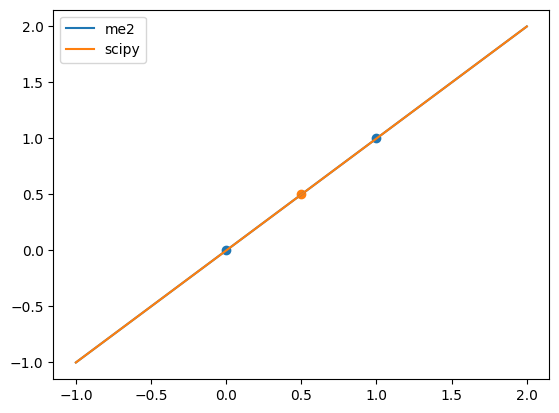

line2 is y = 1.0000157082437229x+-7.85412186143919e-06
real line line is y = 1.0x+0.0


In [52]:
xvals = [0,1]
yvals = [0,1]

complexity = 100000
# slope1, intercept1, theta1, distvals1 = reg(complexity, xvals, yvals)
slope2, intercept2, theta2, distvals2 = reg2(complexity, xvals, yvals)

x = np.linspace(min(xvals) - 1, max(xvals) + 1, 100)

# def regLine(x):
    # return (slope1*x) + intercept1

def regLine2(x):
    return (slope2*x) + intercept2

slopereal, interceptreal, r, p, se = sp.stats.linregress(xvals, yvals)

def realLine(x):
    return (slopereal*x) + interceptreal

# plt.style.use('default_background')
# plt.plot(x, [regLine(i) for i in x], label="me1")
plt.plot(x, [regLine2(i) for i in x], label="me2")
plt.plot(x, [realLine(i) for i in x], label="scipy")
plt.scatter(xvals, yvals)
plt.legend()
plt.scatter(np.mean(xvals), np.mean(yvals))
plt.show()
# print(f"line1 is y = {slope1}x+{intercept1}")
print(f"line2 is y = {slope2}x+{intercept2}")
print(f"real line line is y = {slopereal}x+{interceptreal}")
# plt.plot(theta1, distvals1)
# plt.plot(theta2[:((complexity/2) - 1)], distvals2[:((complexity/2) - 1)])